--- Training Results ---
Estimated Bias (True=0): 2.7488
Estimated X1^2 (True=100): 99.3241
Estimated X2^2 (True=1): 0.2457

Estimated Cost: 1.9481



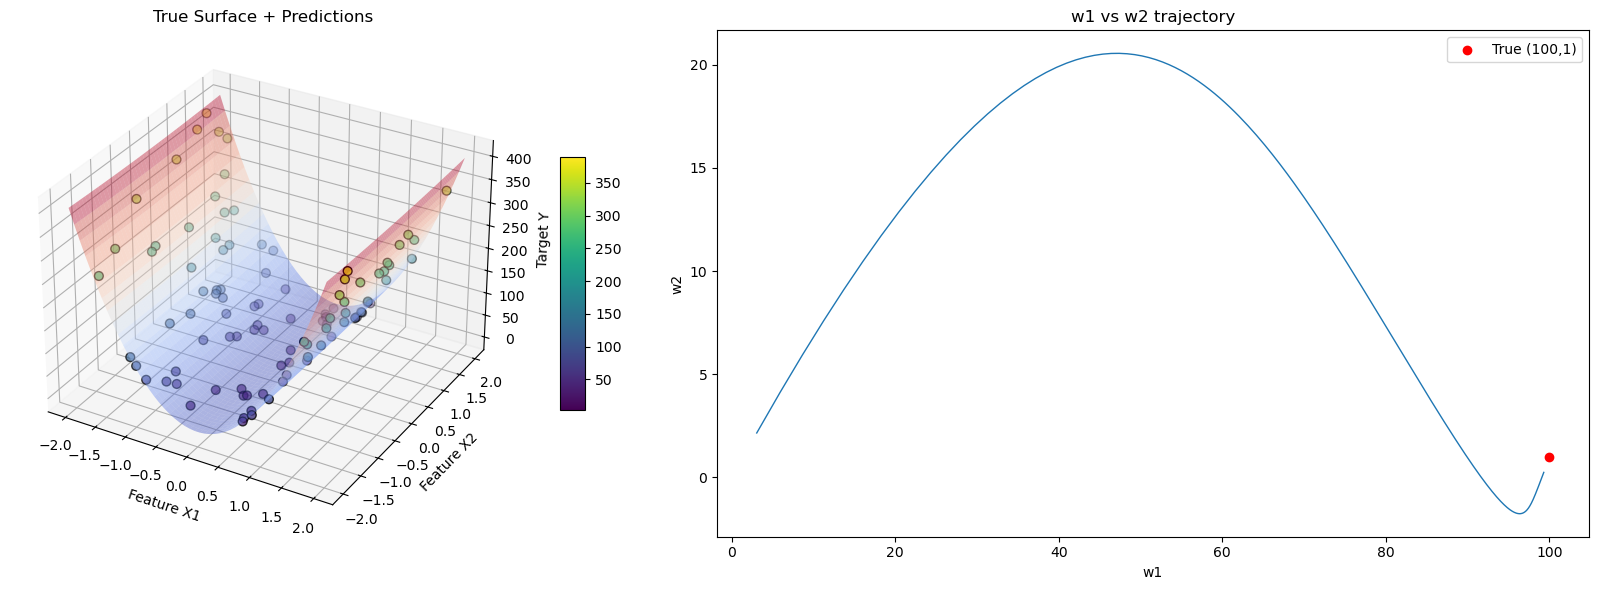

In [9]:
import numpy as np 
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(42)

# 1. Generate random, independent training data (30 samples)
x1 = np.random.uniform(-2, 2, 30)
x2 = np.random.uniform(-2, 2, 30)
X = np.column_stack([np.ones(30), x1 ** 2, x2 ** 2])

y_true = 100 * (x1 ** 2) + (x2 ** 2)
y = y_true + np.random.normal(0, 0.3, 30)

# 2. Hyperparameters & initial weights
# Note: To get the weights even closer to [0, 100, 1], you can change epochs to 10000
eta = 0.01
epochs = 1000
weights = np.random.rand(3) * 0.1
costs = []
w1_history = []
w2_history = []

# 3. Gradient Descent Loop
for epoch in range(epochs):
    yhat = X @ weights
    errors = yhat - y

    # Compute MSE gradients and update weights
    gradients = (X.T @ errors) / len(y)
    weights -= eta * gradients
    w1_history.append(weights[1])
    w2_history.append(weights[2])   

    cost = np.mean(errors ** 2)
    costs.append(cost)

print("--- Training Results ---")
print(f"Estimated Bias (True=0): {weights[0]:.4f}")
print(f"Estimated X1^2 (True=100): {weights[1]:.4f}")
print(f"Estimated X2^2 (True=1): {weights[2]:.4f}\n")
print(f"Estimated Cost: {costs[-1]:.4f}\n")

x1_plot = np.random.uniform(-2, 2, 100)
x2_plot = np.random.uniform(-2, 2, 100)

X_for_testing = np.column_stack([np.ones(100), x1_plot ** 2, x2_plot ** 2])
y_plot = X_for_testing @ weights

x1_line = np.linspace(-2, 2, 50)
x2_line = np.linspace(-2, 2, 50)
X1_mesh, X2_mesh = np.meshgrid(x1_line, x2_line)

Y_mesh = 100 * (X1_mesh ** 2) + (X2_mesh ** 2)

fig = plt.figure(figsize=(18, 6))

# ---------------- 3D surface + scatter ---------------- #
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

surface = ax1.plot_surface(
    X1_mesh, X2_mesh, Y_mesh,
    cmap='coolwarm', alpha=0.4,
    linewidth=0, antialiased=True
)

img = ax1.scatter(
    x1_plot, x2_plot, y_plot,
    c=y_plot, cmap='viridis',
    s=40, edgecolor='k'
)

ax1.set_xlabel('Feature X1')
ax1.set_ylabel('Feature X2')
ax1.set_zlabel('Target Y')
ax1.set_title('True Surface + Predictions')

fig.colorbar(img, ax=ax1, shrink=0.5, aspect=10)


# ---------------- w1-w2 trajectory ---------------- #
ax3 = fig.add_subplot(1,2, 2)

ax3.plot(w1_history, w2_history, linewidth=1)
ax3.scatter([100], [1], color='red', label='True (100,1)')

ax3.set_title("w1 vs w2 trajectory")
ax3.set_xlabel("w1")
ax3.set_ylabel("w2")
ax3.legend()

plt.tight_layout()
plt.show()

--- Training Results ---
Estimated Bias (True=0): -0.0379
Estimated X1^2 (True=100): 100.0445
Estimated X2^2 (True=1): 0.9980

Estimated Cost: 0.0689



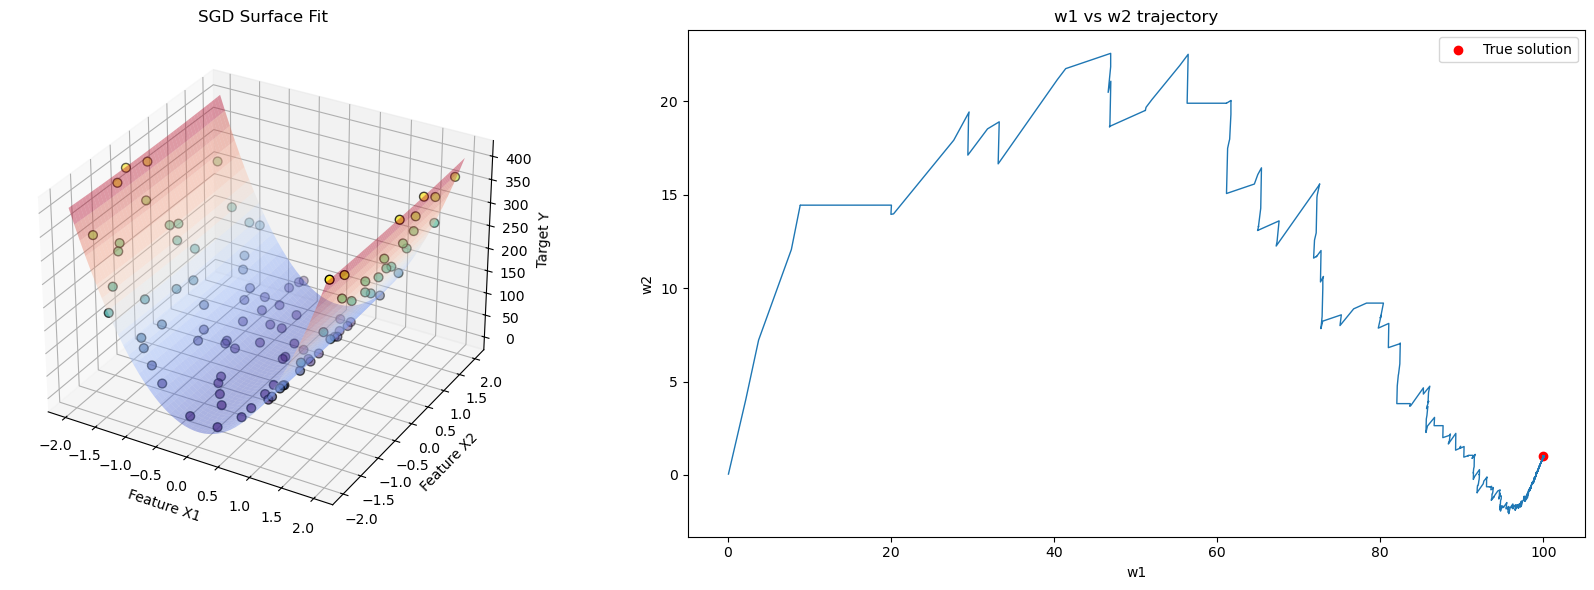

In [8]:
import numpy as np 
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

x1 = np.random.uniform(-2, 2, 30)
x2 = np.random.uniform(-2, 2, 30)

X = np.column_stack([np.ones(30), x1 ** 2, x2 ** 2])

y_true = 100 * (x1 ** 2) + (x2 ** 2)
y = y_true + np.random.normal(0, 0.3, 30)

eta = 0.01
epochs = 1000
weights = np.random.rand(3) * 0.1

costs = []
w1_history = []
w2_history = []

for epoch in range(epochs):

    indices = np.random.permutation(len(y))
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(len(y)):

        xi = X_shuffled[i]
        yi = y_shuffled[i]

        yhat = xi @ weights
        error = yhat - yi

        gradient = xi * error
        weights -= eta * gradient
        w1_history.append(weights[1])
        w2_history.append(weights[2])

    yhat_all = X @ weights
    cost = np.mean((yhat_all - y) ** 2)
    costs.append(cost)

print("--- Training Results ---")
print(f"Estimated Bias (True=0): {weights[0]:.4f}")
print(f"Estimated X1^2 (True=100): {weights[1]:.4f}")
print(f"Estimated X2^2 (True=1): {weights[2]:.4f}\n")
print(f"Estimated Cost: {costs[-1]:.4f}\n")

x1_plot = np.random.uniform(-2, 2, 100)
x2_plot = np.random.uniform(-2, 2, 100)

X_for_testing = np.column_stack([np.ones(100), x1_plot ** 2, x2_plot ** 2])
y_plot = X_for_testing @ weights

x1_line = np.linspace(-2, 2, 50)
x2_line = np.linspace(-2, 2, 50)
X1_mesh, X2_mesh = np.meshgrid(x1_line, x2_line)

Y_mesh = 100 * (X1_mesh ** 2) + (X2_mesh ** 2)

fig = plt.figure(figsize=(18, 6))

# ---------------- 3D Surface ---------------- #
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

ax1.plot_surface(X1_mesh, X2_mesh, Y_mesh, cmap='coolwarm', alpha=0.4)
ax1.scatter(x1_plot, x2_plot, y_plot, c=y_plot, cmap='viridis', s=40, edgecolor='k')

ax1.set_xlabel('Feature X1')
ax1.set_ylabel('Feature X2')
ax1.set_zlabel('Target Y')
ax1.set_title('SGD Surface Fit')



# ---------------- w1 vs w2 trajectory ---------------- #
ax3 = fig.add_subplot(1, 2, 2)

ax3.plot(w1_history, w2_history, linewidth=1)
ax3.scatter([100], [1], color='red', label='True solution')

ax3.set_title("w1 vs w2 trajectory")
ax3.set_xlabel("w1")
ax3.set_ylabel("w2")
ax3.legend()

plt.tight_layout()
plt.show()

--- Training Results ---
Estimated Bias (True=0): -0.0409
Estimated X1^2 (True=100): 100.0460
Estimated X2^2 (True=1): 1.0023

Estimated Cost: 0.0689



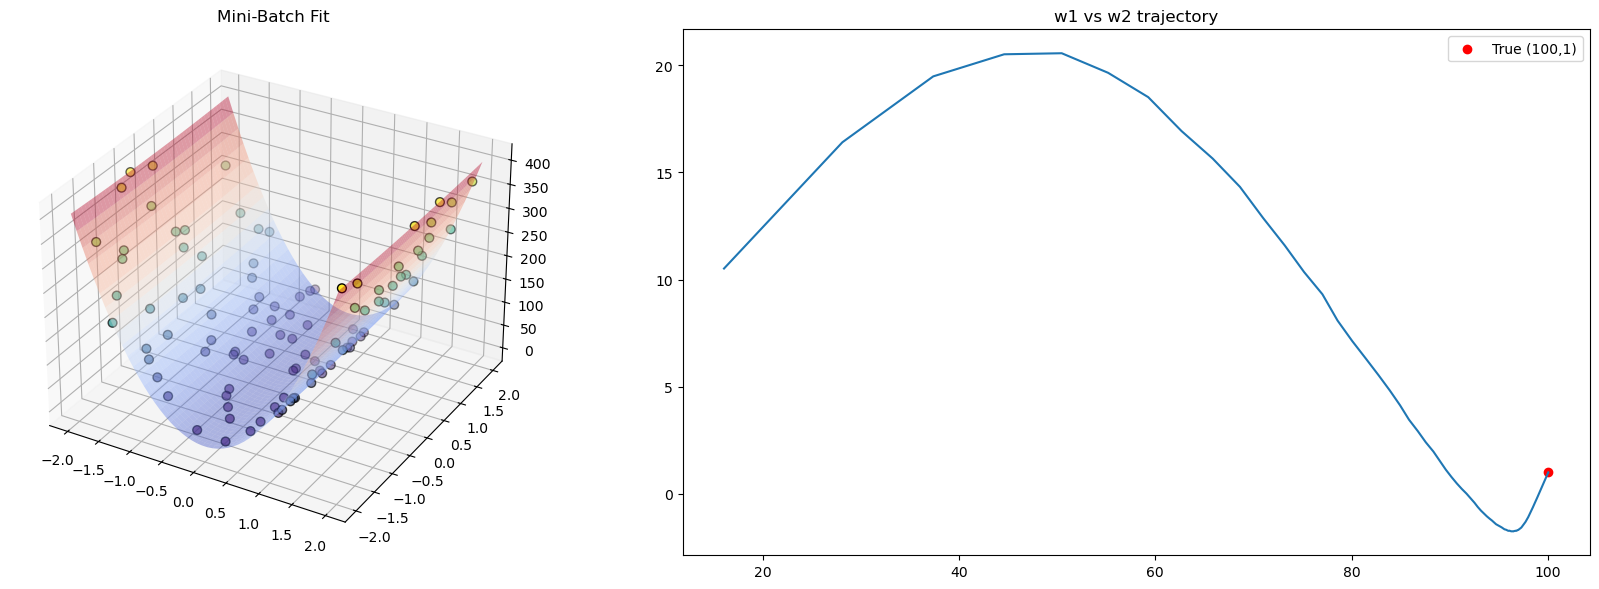

In [7]:
import numpy as np 
import matplotlib.pyplot as plt

np.random.seed(42)

x1 = np.random.uniform(-2, 2, 30)
x2 = np.random.uniform(-2, 2, 30)

X = np.column_stack([np.ones(30), x1 ** 2, x2 ** 2])

y_true = 100 * (x1 ** 2) + (x2 ** 2)
y = y_true + np.random.normal(0, 0.3, 30)

eta = 0.01
epochs = 1000
batch_size = 5

weights = np.random.rand(3) * 0.1

costs = []
w1_history = []
w2_history = []

n = len(y)

for epoch in range(epochs):

    indices = np.random.permutation(n)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(0, n, batch_size):

        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        yhat = X_batch @ weights
        error = yhat - y_batch

        gradient = (X_batch.T @ error) / len(X_batch)
        weights -= eta * gradient

    w1_history.append(weights[1])
    w2_history.append(weights[2])

    yhat_all = X @ weights
    costs.append(np.mean((yhat_all - y) ** 2))

# ---------------- visualization data ---------------- #
print("--- Training Results ---")
print(f"Estimated Bias (True=0): {weights[0]:.4f}")
print(f"Estimated X1^2 (True=100): {weights[1]:.4f}")
print(f"Estimated X2^2 (True=1): {weights[2]:.4f}\n")
print(f"Estimated Cost: {costs[-1]:.4f}\n")


x1_plot = np.random.uniform(-2, 2, 100)
x2_plot = np.random.uniform(-2, 2, 100)

X_for_testing = np.column_stack([np.ones(100), x1_plot ** 2, x2_plot ** 2])
y_plot = X_for_testing @ weights

x1_line = np.linspace(-2, 2, 50)
x2_line = np.linspace(-2, 2, 50)
X1_mesh, X2_mesh = np.meshgrid(x1_line, x2_line)

Y_mesh = 100 * (X1_mesh ** 2) + (X2_mesh ** 2)

# ---------------- PLOTS ---------------- #

fig = plt.figure(figsize=(18, 6))

# 3D surface
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X1_mesh, X2_mesh, Y_mesh, cmap='coolwarm', alpha=0.4)
ax1.scatter(x1_plot, x2_plot, y_plot, c=y_plot, cmap='viridis', s=40, edgecolor='k')
ax1.set_title("Mini-Batch Fit")


# trajectory
ax3 = fig.add_subplot(1, 2, 2)
ax3.plot(w1_history, w2_history)
ax3.scatter([100], [1], color='red', label="True (100,1)")
ax3.set_title("w1 vs w2 trajectory")
ax3.legend()

plt.tight_layout()
plt.show()